In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

In [13]:
data = load_iris()
# display(data)
X = data.data
Y = data.target
print(np.unique(Y))
print(dir(data))

[0 1 2]
['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [17]:
# print(X.shape)
# print(Y.shape)

print(data.data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

1. Load the data
sklearn has Iris built in: from sklearn.datasets import load_iris. Explore it first — check the shape of the features, what the 3 target classes are, and look at a few rows before doing anything else.
2. Split into train and test sets
Use train_test_split from sklearn.model_selection. This is new compared to XOR — think about why holding out data now finally lets you check for overfitting.
3. Scale the features
Look up StandardScaler from sklearn.preprocessing. Investigate why unscaled features can hurt an MLP's training — look at the actual value ranges of the 4 Iris features first to see why this might matter here but didn't for XOR.
4. Build and train the MLP
Use MLPClassifier again, but now think about how many output units you need for 3 classes instead of 2. Pick a hidden_layer_sizes to start with — doesn't need to be perfect yet.
5. Check training vs test performance
Compare model accuracy (or loss) on the training set vs the held-out test set. A meaningful gap between the two is what overfitting actually looks like — something you couldn't observe with only 4 XOR points.
6. Experiment with capacity and see overfitting for real
Try a very large hidden_layer_sizes (e.g. (100,100)) with a small training set and see if train accuracy shoots up while test accuracy lags behind or drops. This is the experiment you couldn't run on XOR.

In [6]:
# check and learn the data
print(data.feature_names)
print(data.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [11]:
print(len(X))
print(len(Y))

150
150


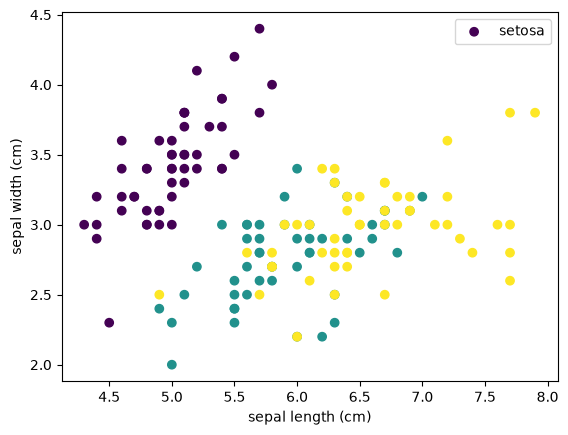

In [23]:
# plt.plot(X, Y) # what is this plot? I don't know, I just try it...
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
# plt.legend([data.target_names[0], data.target_names[1], data.target_names[2]]) # this isn't working
plt.show()

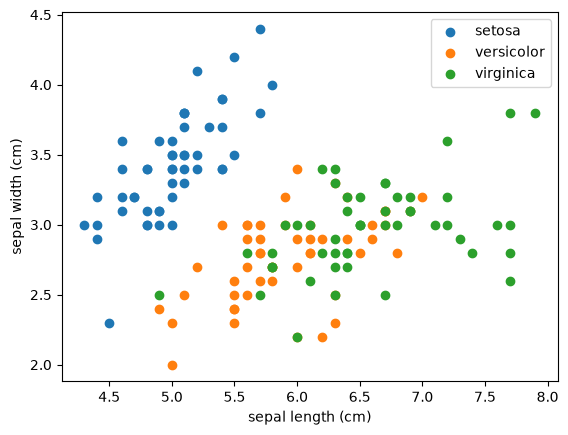

In [24]:
for i in range(3):
    plt.scatter(X[Y == i, 0], X[Y == i, 1], label=data.target_names[i])

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.legend()
plt.show()

In [32]:
# split data
X_train, X_test,Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 55)
print(len(X_train))
print(len(Y_train))

105
105


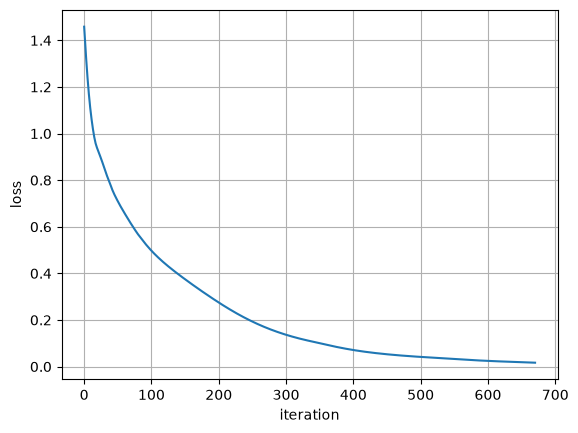

In [80]:
model = MLPClassifier(hidden_layer_sizes = (32,16, ), random_state = 55, max_iter = 10000)
model.fit(X_train, Y_train)
plt.plot(model.loss_curve_)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.grid()
plt.show()

In [81]:
prediction = model.predict(X_test)
print(prediction)
print("loss:",model.loss_)
print("accuracy:",accuracy_score(Y_test, prediction))

[0 0 0 2 2 0 2 2 0 0 0 1 2 0 2 2 1 0 1 2 1 2 2 2 1 1 2 1 2 1 0 0 2 2 0 1 1
 0 2 1 2 0 1 0 1]
loss: 0.016757637663543747
accuracy: 0.9333333333333333


In [82]:
scores = cross_val_score(model, X_test, Y_test, cv=5)
print(scores)
print(scores.mean(), scores.std())

[0.88888889 1.         1.         1.         0.88888889]
0.9555555555555555 0.054433105395181765


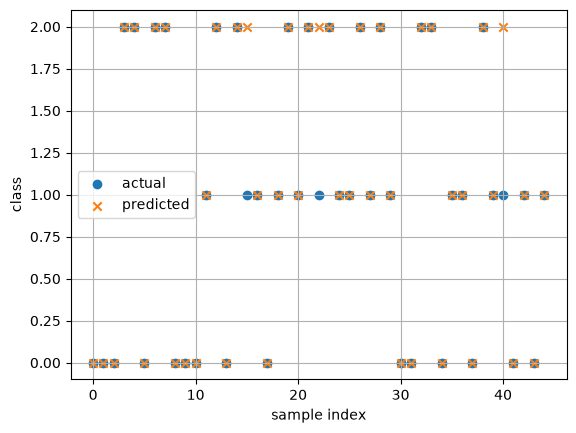

In [86]:
plt.scatter(range(len(Y_test)), Y_test, label='actual', marker='o')
plt.scatter(range(len(prediction)), prediction, label='predicted', marker='x')
plt.xlabel('sample index')
plt.ylabel('class')
plt.legend()
plt.grid()
plt.show()